Импорт необходимых библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# **Загрузка и первичный анализ данных**

In [ ]:
# Загрузка данных Titanic
# Используем встроенный датасет из seaborn
titanic_data = sns.load_dataset('titanic')
# Общая информация о датасете
print(f"\nРазмер датасета: {titanic_data.shape[0]} строк, {titanic_data.shape[1]} столбцов")
print(f"\nСписок признаков:\n{titanic_data.columns.tolist()}")

# Информация о типах данных и пропусках
titanic_data.info()

# Первые 5 строк данных
display(titanic_data.head())

# Статистическое описание числовых признаков
display(titanic_data.describe())


Размер датасета: 891 строк, 15 столбцов

Список признаков:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **Обработка пропусков в данных**

In [ ]:
# Создаем копию данных для работы
df_missing = titanic_data.copy()
# Анализ пропусков по каждому столбцу
missing_counts = df_missing.isnull().sum()
missing_percentages = (df_missing.isnull().sum() / len(df_missing)) * 100

missing_summary = pd.DataFrame({
    'Количество пропусков': missing_counts,
    'Процент пропусков': missing_percentages
})

# Сортируем по убыванию количества пропусков
missing_summary = missing_summary[missing_summary['Количество пропусков'] > 0].sort_values('Количество пропусков', ascending=False)
display(missing_summary)


,Количество пропусков,Процент пропусков
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


In [ ]:
# Выбираем признаки для демонстрации
# Для числовых признаков: age
# Для категориальных: embarked, embark_town
# deck имеет слишком много пропусков, его можно удалить

# Создаем копию данных для экспериментов
df_demo = titanic_data[['age', 'embarked', 'fare', 'pclass']].copy()
print("\nИсходные данные (с пропусками):")
display(df_demo.head(10))

# Удаление строк с пропусками (dropna)
df_dropna = df_demo.dropna()
print(f"\n1. Удаление строк с пропусками:")
print(f"   - Было строк: {len(df_demo)}")
print(f"   - Стало строк: {len(df_dropna)}")
print(f"   - Удалено строк: {len(df_demo) - len(df_dropna)}")

# Заполнение числового признака (age) средним значением
df_mean_impute = df_demo.copy()
mean_age = df_mean_impute['age'].mean()
df_mean_impute['age_filled_mean'] = df_mean_impute['age'].fillna(mean_age)
print(f"\n2. Заполнение age средним значением: {mean_age:.2f}")

# Заполнение категориального признака (embarked) модой
df_mode_impute = df_demo.copy()
mode_embarked = df_mode_impute['embarked'].mode()[0]
df_mode_impute['embarked_filled'] = df_mode_impute['embarked'].fillna(mode_embarked)
print(f"\n4. Заполнение embarked модой: {mode_embarked}")

# Демонстрация результатов
display(df_demo[df_demo['age'].isna()].head(5))


Исходные данные (с пропусками):


,age,embarked,fare,pclass
0,22.0,S,7.2500,3
1,38.0,C,71.2833,1
2,26.0,S,7.9250,3
3,35.0,S,53.1000,1
4,35.0,S,8.0500,3
5,NaN,Q,8.4583,3
6,54.0,S,51.8625,1
7,2.0,S,21.0750,3
8,27.0,S,11.1333,3
9,14.0,C,30.0708,2



1. Удаление строк с пропусками:
   - Было строк: 891
   - Стало строк: 712
   - Удалено строк: 179

2. Заполнение age средним значением: 29.70

4. Заполнение embarked модой: S


,age,embarked,fare,pclass
5,NaN,Q,8.4583,3
17,NaN,S,13.0000,2
19,NaN,C,7.2250,3
26,NaN,C,7.2250,3
28,NaN,Q,7.8792,3


# **Кодирование категориальных признаков**

In [ ]:
# Подготовка данных с категориальными признаками
df_cat = titanic_data[['sex', 'embarked', 'class', 'who', 'survived']].copy()

# Удаляем пропуски для простоты демонстрации
df_cat = df_cat.dropna()

print("\nУникальные значения каждого категориального признака:")
for col in ['sex', 'embarked', 'class', 'who']:
    print(f"  {col}: {df_cat[col].unique().tolist()}")

print("\nПервые 10 строк исходных данных:")
display(df_cat.head(10))


Уникальные значения каждого категориального признака:
  sex: ['male', 'female']
  embarked: ['S', 'C', 'Q']
  class: ['Third', 'First', 'Second']
  who: ['man', 'woman', 'child']

Первые 10 строк исходных данных:


,sex,embarked,class,who,survived
0,male,S,Third,man,0
1,female,C,First,woman,1
2,female,S,Third,woman,1
3,female,S,First,woman,1
4,male,S,Third,man,0
5,male,Q,Third,man,0
6,male,S,First,man,0
7,male,S,Third,child,0
8,female,S,Third,woman,1
9,female,C,Second,child,1


# **One-Hot Encoding**

In [ ]:
# One-Hot Encoding для признака embarked (S, C, Q)
df_onehot = df_cat.copy()

onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
embarked_encoded = onehot_encoder.fit_transform(df_onehot[['embarked']])

# Создаем DataFrame с закодированными признаками
embarked_columns = [f'embarked_{cat}' for cat in onehot_encoder.categories_[0]]
df_embarked_encoded = pd.DataFrame(embarked_encoded, columns=embarked_columns, index=df_onehot.index)

# Объединяем с исходными данными
df_onehot = pd.concat([df_onehot, df_embarked_encoded], axis=1)

print("One-Hot Encoding для признака 'embarked':")
print(f"Исходные категории: {onehot_encoder.categories_[0].tolist()}")
print(f"Создано столбцов: {len(embarked_columns)}")

print("\nРезультат One-Hot Encoding:")
display(df_onehot[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].head(10))

One-Hot Encoding для признака 'embarked':
Исходные категории: ['C', 'Q', 'S']
Создано столбцов: 3

Результат One-Hot Encoding:


,embarked,embarked_C,embarked_Q,embarked_S
0,S,0.0,0.0,1.0
1,C,1.0,0.0,0.0
2,S,0.0,0.0,1.0
3,S,0.0,0.0,1.0
4,S,0.0,0.0,1.0
5,Q,0.0,1.0,0.0
6,S,0.0,0.0,1.0
7,S,0.0,0.0,1.0
8,S,0.0,0.0,1.0
9,C,1.0,0.0,0.0


# **Масштабирование данных**

Формула: X_scaled = (X - min) / (max - min)

Диапазоны после нормализации:
  age: min=0.00, max=1.00
  fare: min=0.00, max=1.00
  sibsp: min=0.00, max=1.00
  parch: min=0.00, max=1.00

Первые 5 строк после MinMaxScaler:


,age,fare,sibsp,parch
0,0.271174,0.014151,0.2,0.0
1,0.472229,0.139136,0.2,0.0
2,0.321438,0.015469,0.0,0.0
3,0.434531,0.103644,0.2,0.0
4,0.434531,0.015713,0.0,0.0


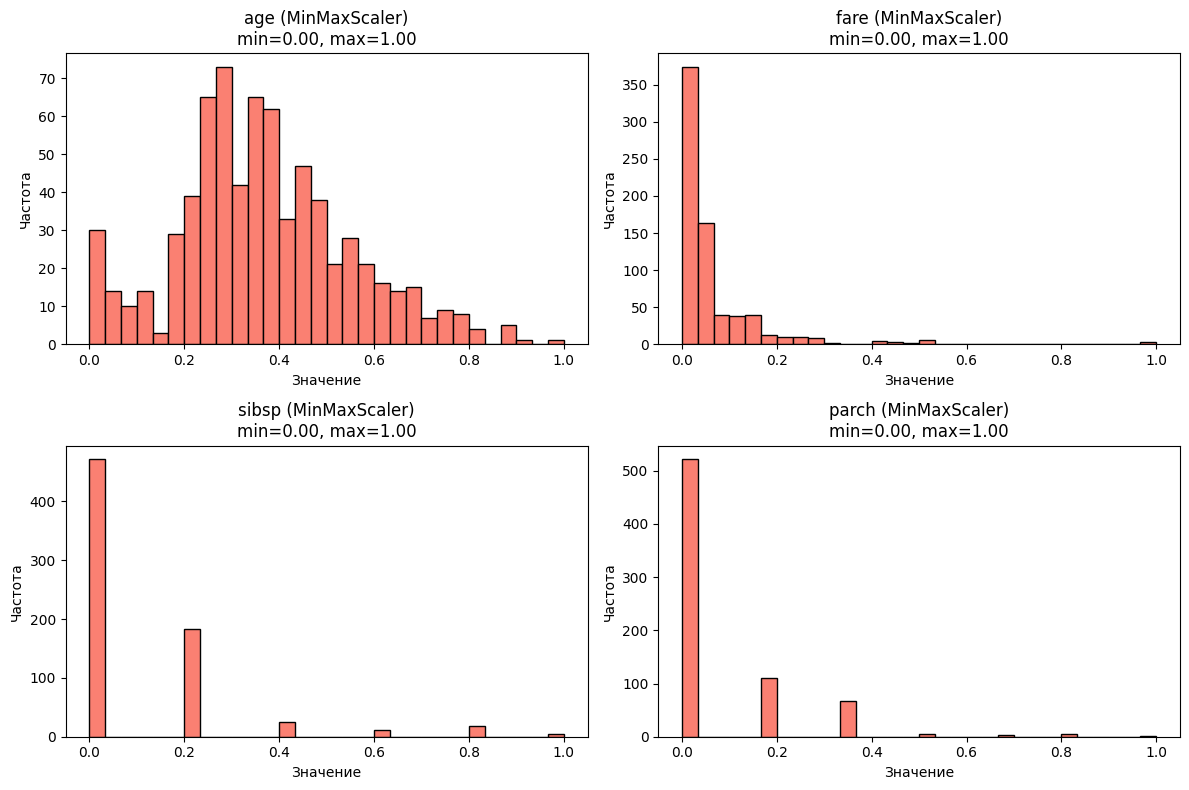

In [ ]:
scaler_minmax = MinMaxScaler()
df_minmax = scaler_minmax.fit_transform(df_scaling)
df_minmax = pd.DataFrame(df_minmax, columns=df_scaling.columns, index=df_scaling.index)

print("Формула: X_scaled = (X - min) / (max - min)")
print(f"\nДиапазоны после нормализации:")
for col in df_minmax.columns:
    print(f"  {col}: min={df_minmax[col].min():.2f}, max={df_minmax[col].max():.2f}")

print("\nПервые 5 строк после MinMaxScaler:")
display(df_minmax.head(5))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, col in enumerate(df_minmax.columns):
    axes[idx].hist(df_minmax[col], bins=30, color='salmon', edgecolor='black')
    axes[idx].set_title(f'{col} (MinMaxScaler)\nmin={df_minmax[col].min():.2f}, max={df_minmax[col].max():.2f}')
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()